Celda 1: Importaciones y Estructuras Base

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# 1. Catálogo (Tuplas) y Precios/Stock (Diccionarios)
CATALOGO = (
    ("P001", "Laptop"),
    ("P002", "Mouse"),
    ("P003", "Teclado"),
    ("P004", "Monitor")
)

precios = {
    "P001": 800.0,
    "P002": 25.0,
    "P003": 45.0,
    "P004": 200.0
}

stock = {
    "P001": 15,
    "P002": 50,
    "P003": 30,
    "P004": 20
}

# Buffer en lista para registrar ventas temporalmente
buffer_ventas = []

Celda 2: Funciones de Errores, Archivos y Log (Reto D)

In [2]:
def registrar_log(mensaje):
    """Reto D: Escribe intentos fallidos o eventos en log.txt"""
    try:
        with open("log.txt", "a", encoding="utf-8") as f:
            f.write(f"{mensaje}\n")
    except Exception as e:
        print(f"Error escribiendo en log: {e}")

def cargar_ventas_csv(ruta):
    """Carga y maneja errores con try/except/else/finally"""
    path = Path(ruta)
    df = None
    try:
        if not path.exists():
            raise FileNotFoundError(f"El archivo '{ruta}' no existe.")

        df = pd.read_csv(ruta)
        if df.empty:
            print(f"Aviso: El archivo '{ruta}' está vacío.")
    except FileNotFoundError as fnf:
        print(f"Error: {fnf}")
        registrar_log(f"FileNotFound: {fnf}")
    except pd.errors.EmptyDataError:
        print(f"Error: El archivo CSV está vacío o corrupto.")
        registrar_log("EmptyDataError en CSV.")
    except Exception as e:
        print(f"Error inesperado al cargar: {e}")
        registrar_log(f"Error inesperado: {e}")
    else:
        print(f"¡Archivo '{ruta}' cargado exitosamente!")
    finally:
        print("Proceso de carga finalizado.\n")
    return df

Celda 3: Lógica de Negocio, Ventas y Retos (A, C, D)

In [3]:
def agregar_producto(cat, prec, sto):
    """Reto A: Agrega un producto nuevo al catálogo y actualiza precios/stock"""
    global CATALOGO
    pid = input("Ingrese el ID del nuevo producto (ej: P005): ").strip().upper()

    # Validar si ya existe
    ids_existentes = [item[0] for item in CATALOGO]
    if pid in ids_existentes:
        print("Error: El ID ya existe en el catálogo.")
        return

    nombre = input("Ingrese el nombre del producto: ").strip()
    try:
        precio = float(input("Ingrese el precio unitario: "))
        cantidad = int(input("Ingrese el stock inicial: "))
        if precio <= 0 or cantidad < 0:
            raise ValueError("El precio debe ser mayor a 0 y el stock no negativo.")
    except ValueError as ve:
        print(f"Entrada inválida: {ve}")
        return

    # Actualizar tupla convirtiéndola temporalmente o reasignando
    CATALOGO = CATALOGO + ((pid, nombre),)
    prec[pid] = precio
    sto[pid] = cantidad
    print(f"¡Producto '{nombre}' agregado exitosamente al catálogo!")

def registrar_venta(buffer, prec, sto):
    """Registra una venta con validación de ID (Reto D) y descuento por cantidad (Reto C)"""
    pid = input("Ingrese el ID del producto a vender: ").strip().upper()

    # Reto D: Validar si el ID está en el diccionario de precios/stock
    if pid not in prec:
        error_msg = f"Intento fallido de venta: ID '{pid}' no existe en el catálogo."
        print(f"Error: {error_msg}")
        registrar_log(error_msg)
        return

    try:
        cantidad = int(input("Ingrese la cantidad a vender: "))
        if cantidad <= 0:
            print("La cantidad debe ser mayor a cero.")
            return
    except ValueError:
        print("Error: Debe ingresar un número entero válido.")
        return

    # Validar stock disponible
    if stock[pid] < cantidad:
        print(f"Stock insuficiente. Stock actual: {stock[pid]}")
        return

    # Actualizar stock
    stock[pid] -= cantidad
    precio_unitario = prec[pid]
    subtotal = precio_unitario * cantidad

    # Reto C: Agrega descuento del 5% si unidades >= 10 usando if
    descuento = 0.0
    if cantidad >= 10:
        descuento = subtotal * 0.05
        print("¡Se ha aplicado un 5% de descuento por volumen (>= 10 unidades)!")

    total_pagar = subtotal - descuento

    # Guardar en buffer (lista)
    venta = {
        "producto_id": pid,
        "cantidad": cantidad,
        "precio_unitario": precio_unitario,
        "subtotal": subtotal,
        "descuento": descuento,
        "total": total_pagar
    }
    buffer.append(venta)
    print(f"Venta registrada con éxito. Total a pagar: ${total_pagar:.2f}\n")

Celda 4: Análisis con NumPy, Pandas y Gráficos (Reto B)

In [4]:
def analizar_y_guardar(buffer):
    if not buffer:
        print("No hay ventas registradas para analizar.")
        return None

    # Crear DataFrame con Pandas
    df_ventas = pd.DataFrame(buffer)

    # Guardar en ventas.csv (con al menos 10 ventas o las que existan)
    df_ventas.to_csv("ventas.csv", index=False)
    print("Datos exportados exitosamente a 'ventas.csv'.")

    # Métricas con NumPy sobre los arreglos de ingresos (total) y cantidades
    totales = df_ventas["total"].to_numpy()
    cantidades = df_ventas["cantidad"].to_numpy()

    print("\n--- Métricas Estadísticas (NumPy) ---")
    print(f"Ingreso Promedio por venta: ${np.mean(totales):.2f}")
    print(f"Desviación estándar de ingresos: ${np.std(totales):.2f}")
    print(f"Ingreso Total acumulado: ${np.sum(totales):.2f}")
    print(f"Cantidad total de artículos vendidos: {np.sum(cantidades)}")

    # Análisis con Pandas groupby (Agrupado por producto)
    resumen = df_ventas.groupby("producto_id")[["cantidad", "total"]].sum().reset_index()
    print("\n--- Resumen Agrupado por Producto ---")
    print(resumen)

    return resumen, df_ventas

def graficar_ingresos(resumen):
    """Genera gráfica de barras y cumple con el Reto B (guardar a PNG)"""
    if resumen is None or resumen.empty:
        print("No hay datos para graficar.")
        return

    plt.figure(figsize=(8, 5))
    plt.bar(resumen["producto_id"], resumen["total"], color='skyblue', edgecolor='black')
    plt.title("Ingresos Totales por Producto")
    plt.xlabel("Producto ID")
    plt.ylabel("Ingresos ($)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Reto B: Exportar gráfico a PNG usando plt.savefig
    plt.savefig("ingresos.png")
    print("Gráfico guardado exitosamente como 'ingresos.png'.")
    plt.show()

Celda 5: Menú Principal con Bucle while y Control de Flujo


--- SISTEMA MINITIENDA ---
1. Ver Catálogo y Stock
2. Registrar Venta
3. Agregar Nuevo Producto (Reto A)
4. Analizar Ventas y Generar CSV (Pandas/NumPy)
5. Graficar Ingresos por Producto (Matplotlib)
6. Exportar Gráfico a PNG (Reto B)
7. Cargar ventas previas desde CSV
8. Salir
Seleccione una opción (1-8): 2
Ingrese el ID del producto a vender: p001
Ingrese la cantidad a vender: 1
Venta registrada con éxito. Total a pagar: $800.00


--- SISTEMA MINITIENDA ---
1. Ver Catálogo y Stock
2. Registrar Venta
3. Agregar Nuevo Producto (Reto A)
4. Analizar Ventas y Generar CSV (Pandas/NumPy)
5. Graficar Ingresos por Producto (Matplotlib)
6. Exportar Gráfico a PNG (Reto B)
7. Cargar ventas previas desde CSV
8. Salir
Seleccione una opción (1-8): 2
Ingrese el ID del producto a vender: p002
Ingrese la cantidad a vender: 2
Venta registrada con éxito. Total a pagar: $50.00


--- SISTEMA MINITIENDA ---
1. Ver Catálogo y Stock
2. Registrar Venta
3. Agregar Nuevo Producto (Reto A)
4. Analizar Ventas y 

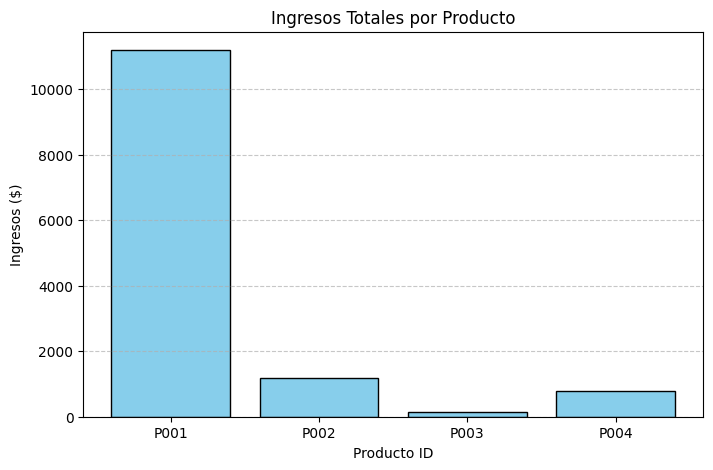


--- SISTEMA MINITIENDA ---
1. Ver Catálogo y Stock
2. Registrar Venta
3. Agregar Nuevo Producto (Reto A)
4. Analizar Ventas y Generar CSV (Pandas/NumPy)
5. Graficar Ingresos por Producto (Matplotlib)
6. Exportar Gráfico a PNG (Reto B)
7. Cargar ventas previas desde CSV
8. Salir
Seleccione una opción (1-8): 8
Saliendo del sistema. ¡Hasta luego!


In [11]:
def menu():
    while True:
        print("\n--- SISTEMA MINITIENDA ---")
        print("1. Ver Catálogo y Stock")
        print("2. Registrar Venta")
        print("3. Agregar Nuevo Producto (Reto A)")
        print("4. Analizar Ventas y Generar CSV (Pandas/NumPy)")
        print("5. Graficar Ingresos por Producto (Matplotlib)")
        print("6. Exportar Gráfico a PNG (Reto B)")
        print("7. Cargar ventas previas desde CSV")
        print("8. Salir")

        opcion = input("Seleccione una opción (1-8): ").strip()

        if opcion == "1":
            print("\nID\tProducto\tPrecio\tStock")
            for pid, nombre in CATALOGO:
                print(f"{pid}\t{nombre}\t\t${precios[pid]:.2f}\t{stock[pid]}")
        elif opcion == "2":
            registrar_venta(buffer_ventas, precios, stock)
        elif opcion == "3":
            agregar_producto(CATALOGO, precios, stock)
        elif opcion == "4":
            resumen, _ = analizar_y_guardar(buffer_ventas)
        elif opcion == "5":
            resumen, _ = analizar_y_guardar(buffer_ventas)
            graficar_ingresos(resumen)
        elif opcion == "6":
            resumen, _ = analizar_y_guardar(buffer_ventas)
            graficar_ingresos(resumen) # La función ya incluye plt.savefig("ingresos.png")
        elif opcion == "7":
            ruta_csv = input("Ingrese la ruta del archivo CSV (ej: ventas.csv): ").strip()
            cargar_ventas_csv(ruta_csv)
        elif opcion == "8":
            print("Saliendo del sistema. ¡Hasta luego!")
            break
        else:
            print("Opción inválida. Por favor, ingrese un número del 1 al 8.")
            continue

# Ejecutar el menú interactivo
menu()

 Preguntas Teóricas

**¿Qué parte la hizo Pandas? ¿Qué parte NumPy?**

Pandas se encargó de estructurar los registros de ventas en un DataFrame bidimensional, permitiendo filtrar, manipular columnas y realizar operaciones de agregación con groupby para agrupar ventas por producto.

NumPy se utilizó para realizar cálculos estadísticos eficientes y vectorizados sobre los arreglos de datos numéricos (como np.mean para el promedio, np.std para la desviación estándar y np.sum para las sumas totales).

**¿Dónde usaste try/except y por qué?**

Se implementó en las funciones de carga de archivos CSV (cargar_ventas_csv) y en la captura de entradas numéricas de los usuarios. Se usa para evitar que el programa colapse (falle por excepciones) ante errores comunes como archivos inexistentes (FileNotFoundError), archivos vacíos (EmptyDataError) o entradas de texto erróneas cuando se espera un número (ValueError).

**¿Qué estructuras son tuplas, listas y diccionarios en el código?**

Tuplas: El catálogo principal de productos (CATALOGO), elegido porque sus elementos son fijos e inmutables durante la ejecución estándar.

Diccionarios: precios y stock, ideales para almacenar pares clave-valor donde la clave es el ID del producto y el valor es su respectivo precio o cantidad disponible.

Listas: El buffer_ventas, utilizado como una lista dinámica para ir acumulando los diccionarios de cada venta registrada antes de convertirlos en un DataFrame de Pandas.